# Classificação de Cogumelos com Árvore de Decisão

Notebook baseado no tutorial [Decision Tree Classification in Python (DataCamp)](https://www.datacamp.com/pt/tutorial/decision-tree-classification-python),
adaptado para o dataset **Mushroom** (UCI Machine Learning Repository).

**Objetivo:** classificar cogumelos como comestíveis (`e`) ou venenosos (`p`) a partir de características físicas.

**Fonte dos dados:** Mushroom [Dataset]. (1981). UCI Machine Learning Repository. https://doi.org/10.24432/C5959T

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import plot_tree
from ucimlrepo import fetch_ucirepo 

## 1. Coleta e preparação dos dados

In [ ]:
mushroom = fetch_ucirepo(id=73)
X = mushroom.data.features
y = mushroom.data.targets['poisonous']

print(mushroom.metadata)
print(mushroom.variables)
print(X.isnull().sum())

X = X.copy()
X['stalk-root'] = X['stalk-root'].fillna('missing')

X_codificado = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X_codificado, y, test_size=0.3, random_state=1)

{'uci_id': 73, 'name': 'Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/73/mushroom', 'data_url': 'https://archive.ics.uci.edu/static/public/73/data.csv', 'abstract': 'From Audobon Society Field Guide; mushrooms described in terms of physical characteristics; classification: poisonous or edible', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 8124, 'num_features': 22, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['poisonous'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1981, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5959T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely po

## 2. Criação do modelo de árvore de decisão

In [46]:
clf = DecisionTreeClassifier()

clf = clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

### 2.1 Avaliação do modelo

In [47]:
print("Acurácia:", metrics.accuracy_score(y_test, y_pred))

Acurácia: 1.0


### 2.2 Visualização da árvore de decisão

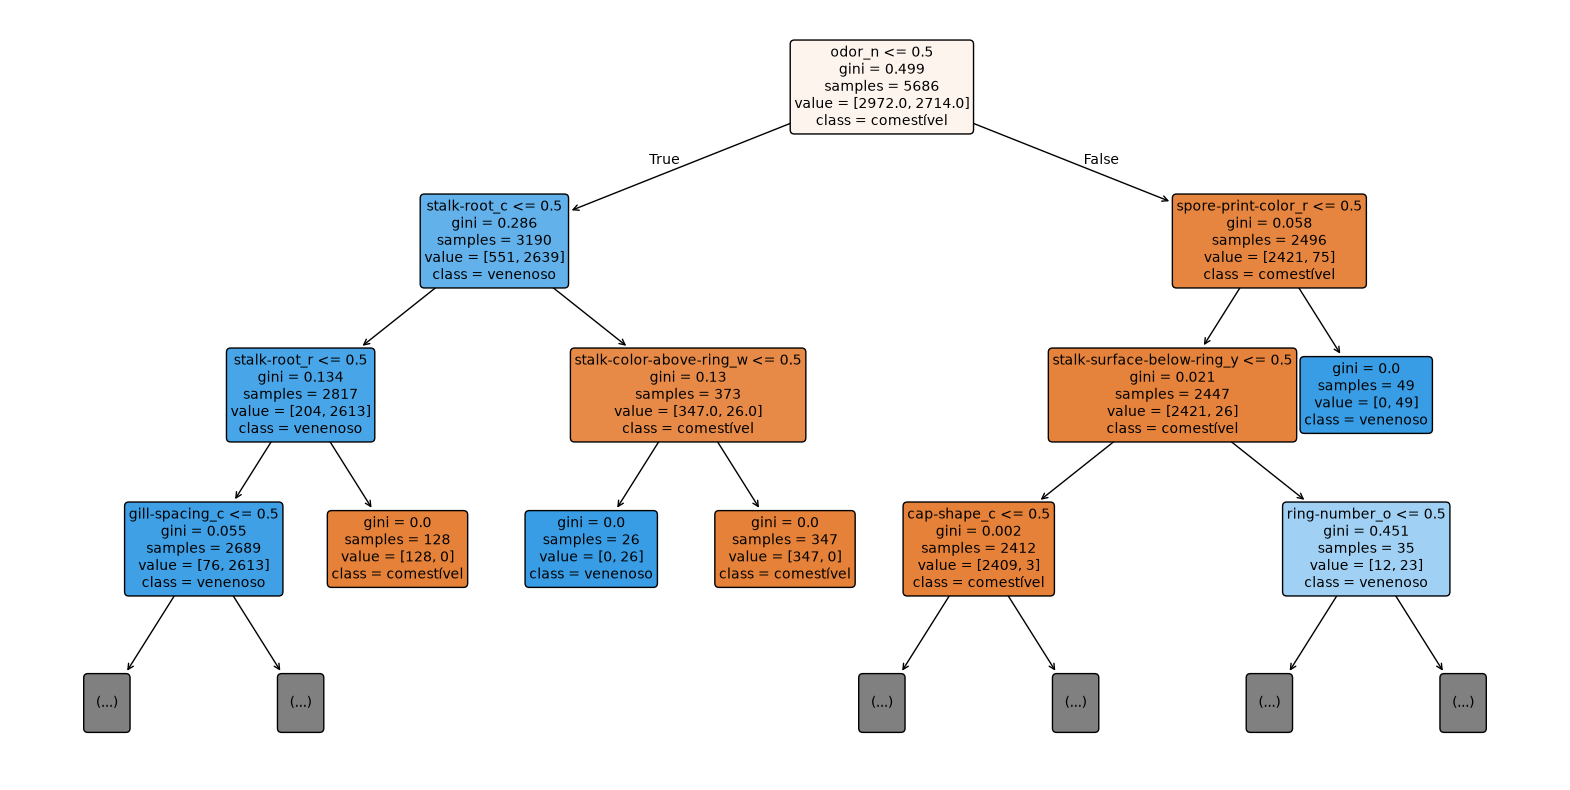

In [ ]:
# max_depth=3 aqui limita só o DESENHO: a árvore treinada continua completa
# (os nós cinza "(...)" são os níveis que ficaram de fora da imagem)
plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=X_codificado.columns,
    class_names=['comestível', 'venenoso'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.show()

## 3. Pré-poda (max_depth=3 + entropy)

In [49]:
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

clf = clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

print("Acurácia:",metrics.accuracy_score(y_test, y_pred))

Acurácia: 0.9618539786710418


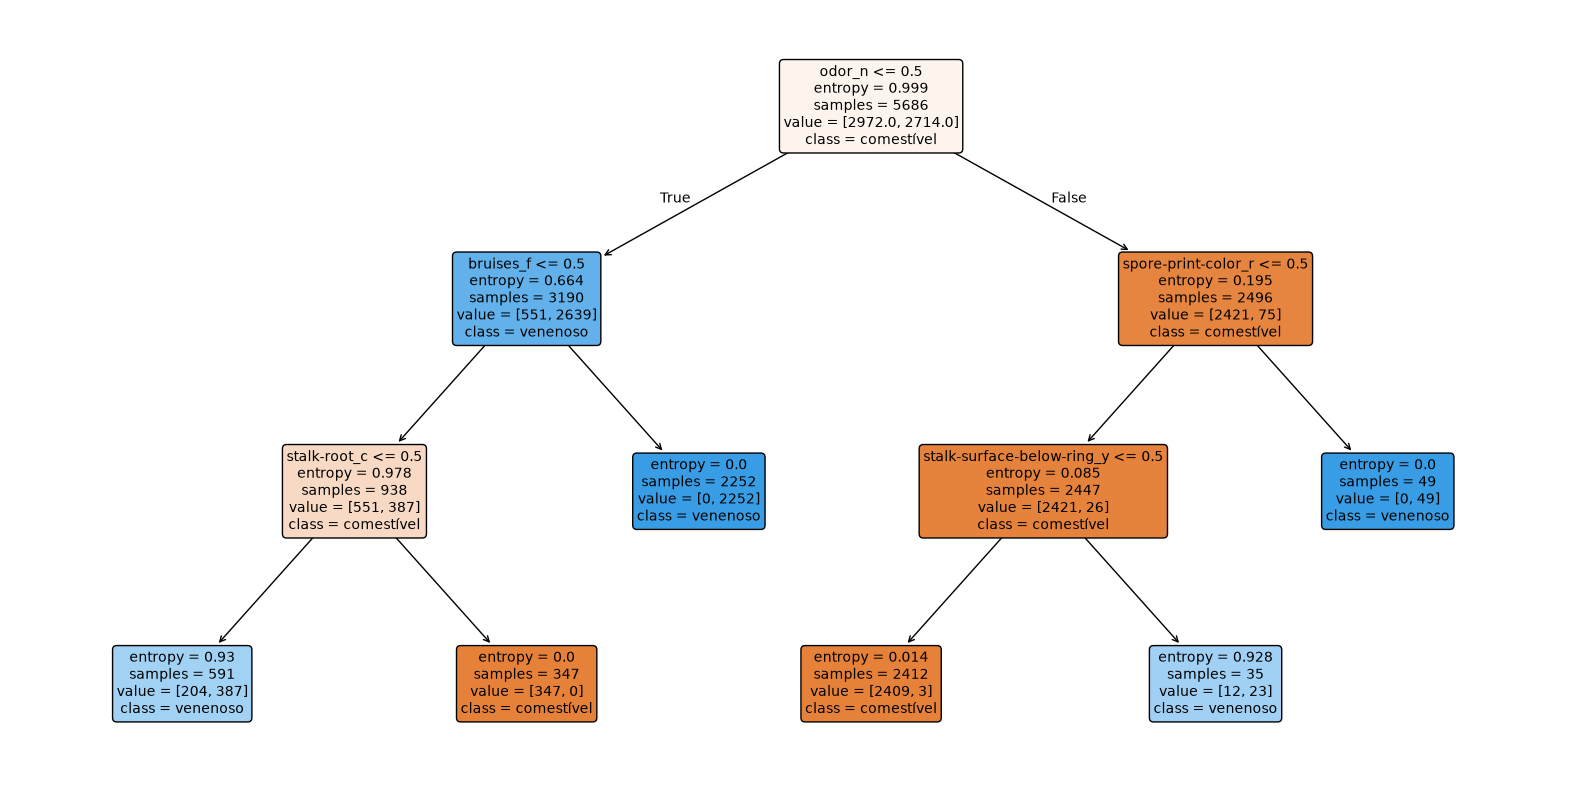

In [ ]:
# A árvore já foi treinada com max_depth=3 (pré-poda), então o plot_tree
# mostra todos os níveis. O max_depth abaixo é redundante e pode ser removido.
plt.figure(figsize=(20, 10))

plot_tree(
    clf,
    feature_names=X_codificado.columns,
    class_names=['comestível', 'venenoso'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.show()

## 4. Conclusões

| Modelo | Acurácia |
|--------|----------|
| Árvore completa | 1.0 |
| Árvore podada (`max_depth=3`, `entropy`) | 0.9619 |

- A árvore completa acerta todos os casos de teste, mas é grande e difícil de interpretar.
- A árvore podada perde cerca de 4 pontos de acurácia, mas cabe em uma única imagem e é fácil de explicar.
- A variável mais importante é `odor` (a raiz da árvore em ambos os modelos).